In [65]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [67]:
def plot_confusion_matrix_matplotlib(cm, title="Confusion matrix", labels=None, savepath=None, figsize=(6,5)):
    plt.figure(figsize=figsize)
    plt.imshow(cm, aspect='auto')
    plt.colorbar()
    if labels is not None:
        plt.xticks(np.arange(len(labels)), labels, rotation=45, ha='right')
        plt.yticks(np.arange(len(labels)), labels)
    else:
        plt.xticks([])
        plt.yticks([])
    # annotate values
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center', color='black', fontsize=8)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

def safe_display_df(df, name=None):
    # Use ace_tools if available; else print head
    try:
        import ace_tools
        ace_tools.display_dataframe_to_user(name or "table", df)
    except Exception:
        display(df)


In [69]:
# -------------------------
# File paths (uploaded)
# -------------------------
train_path = "kdd_train.csv"
test_path  = "kdd_test.csv"

if not (os.path.exists(train_path) and os.path.exists(test_path)):
    raise FileNotFoundError("Expected files at /mnt/data/kdd_train.csv and /mnt/data/kdd_test.csv")

print("Loading files:")
print(" - train:", train_path)
print(" - test: ", test_path)

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print(f"\nTrain shape: {df_train.shape}")
print(f"Test  shape: {df_test.shape}")

safe_display_df(df_train.head(6), "KDD Train - head")
safe_display_df(df_test.head(6), "KDD Test - head")


Loading files:
 - train: kdd_train.csv
 - test:  kdd_test.csv

Train shape: (125973, 42)
Test  shape: (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
5,0,tcp,private,REJ,0,0,0,0,0,0,...,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,5,tcp,smtp,SF,2429,475,0,0,0,0,...,57,0.11,0.02,0.01,0.04,0.0,0.0,0.87,0.0,normal
1,0,udp,domain_u,SF,45,134,0,0,0,0,...,155,0.80,0.02,0.01,0.00,0.0,0.0,0.00,0.0,normal
2,0,udp,domain_u,SF,45,80,0,0,0,0,...,255,1.00,0.00,0.01,0.00,0.0,0.0,0.00,0.0,normal
3,1979,udp,other,SF,145,105,0,0,0,0,...,2,0.01,0.84,1.00,0.00,0.0,0.0,0.00,0.0,normal
4,14462,tcp,other,RSTR,1,0,0,0,0,0,...,2,0.01,0.68,1.00,0.00,0.0,0.0,1.00,1.0,portsweep
5,0,tcp,private,S0,0,0,0,0,0,0,...,9,0.04,0.07,0.00,0.00,1.0,1.0,0.00,0.0,neptune


In [71]:
# -------------------------
# Target column
# -------------------------
target_col = "labels"
if target_col not in df_train.columns:
    raise ValueError(f"Target '{target_col}' not found in train file columns: {df_train.columns.tolist()}")

In [73]:
# -------------------------
# Label encode target (train labels define classes)
# -------------------------
le = LabelEncoder()
y_train_raw = df_train[target_col].astype(str)
y_test_raw  = df_test[target_col].astype(str)

le.fit(y_train_raw)
y_train = le.transform(y_train_raw)


In [75]:
# Map test labels: if unseen label in test, mark as -1
def map_test_label(x):
    # faster mapping using numpy search
    try:
        return int(np.where(le.classes_ == x)[0][0])
    except Exception:
        return -1

y_test_mapped = y_test_raw.apply(map_test_label).astype(int)
unseen_test_labels = sorted(set(y_test_raw[y_test_mapped == -1].unique()))
if unseen_test_labels:
    print("\nWarning: test set contains labels not present in training set (these will be skipped in test evaluation):")
    print(unseen_test_labels)



['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'xlock', 'xsnoop', 'xterm']


In [77]:
# -------------------------
# Feature preprocessing: drop label column, one-hot categorical, align columns
# -------------------------
X_train = df_train.drop(columns=[target_col]).copy()
X_test  = df_test.drop(columns=[target_col]).copy()

cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
print("\nCategorical columns detected:", cat_cols if cat_cols else "None")

X_train_dum = pd.get_dummies(X_train, drop_first=True)
X_test_dum  = pd.get_dummies(X_test, drop_first=True)


Categorical columns detected: ['protocol_type', 'service', 'flag']


In [79]:
# Align columns (ensure same columns/order in train/test)
X_train_dum, X_test_dum = X_train_dum.align(X_test_dum, join='left', axis=1, fill_value=0)

print("\nAfter one-hot encoding shapes:")
print(" X_train:", X_train_dum.shape)
print(" X_test: ", X_test_dum.shape)


After one-hot encoding shapes:
 X_train: (125973, 119)
 X_test:  (22544, 119)


In [81]:
# Remove zero-variance columns (optional)
nunique = X_train_dum.nunique()
zero_var = nunique[nunique <= 1].index.tolist()
if zero_var:
    X_train_dum.drop(columns=zero_var, inplace=True)
    X_test_dum.drop(columns=zero_var, inplace=True)
    print(f"Dropped {len(zero_var)} zero-variance columns")

Dropped 1 zero-variance columns


In [83]:
# -------------------------
# Scale (fit on train only)
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dum)
X_test_scaled  = scaler.transform(X_test_dum)

print("\nNumber of rows: train =", X_train_scaled.shape[0], ", test =", X_test_scaled.shape[0])



Number of rows: train = 125973 , test = 22544


In [85]:
# -------------------------
# Models (speed-conscious settings)
# -------------------------
models = {
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}


In [87]:
# Directory to save confusion matrix images and summary
out_dir = "/mnt/data/kdd_model_outputs"
os.makedirs(out_dir, exist_ok=True)


In [99]:
# --------- Utility plotting functions ----------
def plot_confusion_matrix_matplotlib(cm, title="Confusion matrix", labels=None, savepath=None, figsize=(6,5)):
    plt.figure(figsize=figsize)
    plt.imshow(cm, aspect='auto', cmap='Blues')
    plt.colorbar()
    if labels is not None:
        plt.xticks(np.arange(len(labels)), labels, rotation=45, ha='right')
        plt.yticks(np.arange(len(labels)), labels)
    else:
        plt.xticks([])
        plt.yticks([])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center', color='black', fontsize=8)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150)
    plt.show()

from matplotlib.colors import ListedColormap

def plot_binary_tp_fp_fn_tn(cm, title="TP/FP/FN/TN diagram", savepath=None):
    """
    Perfect 2x2 TP-FP-FN-TN diagram without color errors.
    """
    if cm.shape != (2, 2):
        print(f"{title}: Not a binary 2x2 confusion matrix, skipping.")
        return
    
    TN, FP = int(cm[0,0]), int(cm[0,1])
    FN, TP = int(cm[1,0]), int(cm[1,1])

    # Create numeric 2x2 grid for colors
    color_grid = np.array([
        [0, 1],   # 0 = green, 1 = red
        [1, 0]
    ])

    cmap = ListedColormap(["#A8E6A1", "#F7A3A3"])  # green, red

    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(color_grid, cmap=cmap)

    # Add TP/TN/FP/FN text
    ax.text(0, 0, f"TN\n{TN}", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(1, 0, f"FP\n{FP}", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(0, 1, f"FN\n{FN}", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(1, 1, f"TP\n{TP}", ha='center', va='center', fontsize=12, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Negative", "Pred Positive"])
    ax.set_yticklabels(["Actual Negative", "Actual Positive"])

    plt.title(title)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=150)

    plt.show()



=== Model: LogisticRegression ===

Classification report (TRAIN):
                 precision    recall  f1-score   support

           back       0.98      0.99      0.98       956
buffer_overflow       0.85      0.73      0.79        30
      ftp_write       1.00      0.50      0.67         8
   guess_passwd       0.98      1.00      0.99        53
           imap       1.00      0.91      0.95        11
        ipsweep       0.97      0.98      0.97      3599
           land       0.72      1.00      0.84        18
     loadmodule       1.00      0.33      0.50         9
       multihop       1.00      0.29      0.44         7
        neptune       1.00      1.00      1.00     41214
           nmap       0.93      0.95      0.94      1493
         normal       0.99      1.00      0.99     67343
           perl       0.67      0.67      0.67         3
            phf       1.00      1.00      1.00         4
            pod       1.00      1.00      1.00       201
      portsweep     

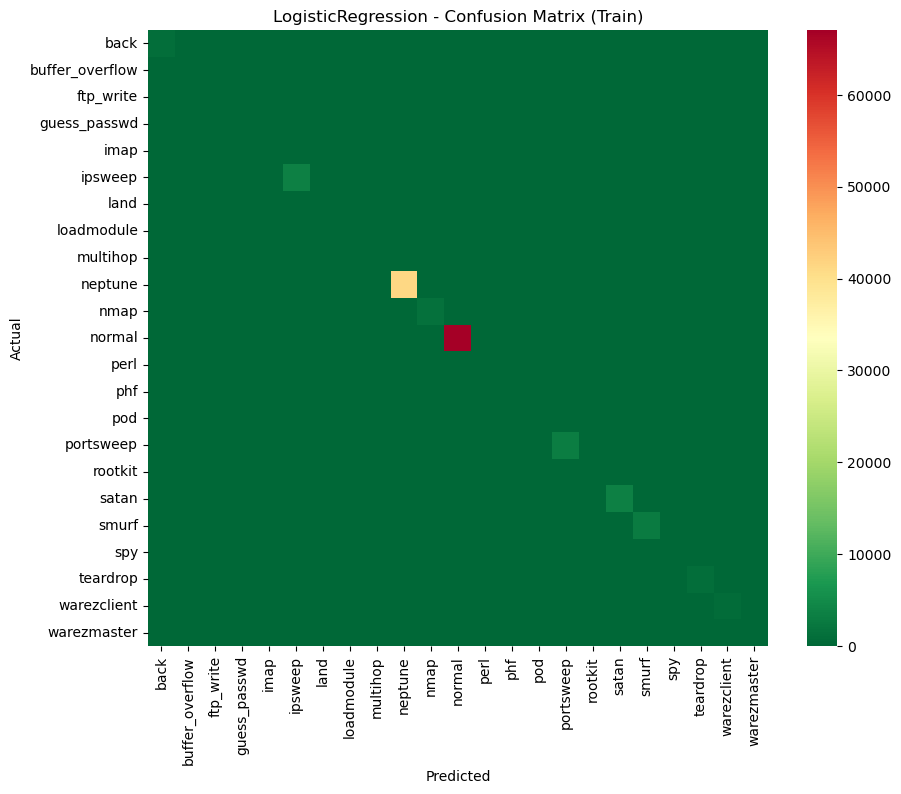

Saved TRAIN CM: /mnt/data/kdd_model_outputs\LogisticRegression_train_cm.png
Training Accuracy: 0.9932

Classification report (TEST - valid labels only):
                 precision    recall  f1-score   support

           back       0.99      0.84      0.91       227
buffer_overflow       1.00      0.29      0.45        17
      ftp_write       0.25      0.50      0.33         2
   guess_passwd       1.00      0.02      0.04       411
           imap       1.00      0.50      0.67         2
        ipsweep       0.98      0.97      0.98       479
           land       1.00      1.00      1.00         2
     loadmodule       1.00      0.25      0.40         4
       multihop       0.00      0.00      0.00         9
        neptune       1.00      1.00      1.00      6654
           nmap       0.95      0.95      0.95       206
         normal       0.93      0.98      0.96     11245
           perl       0.00      0.00      0.00         1
            phf       1.00      1.00      1.00  

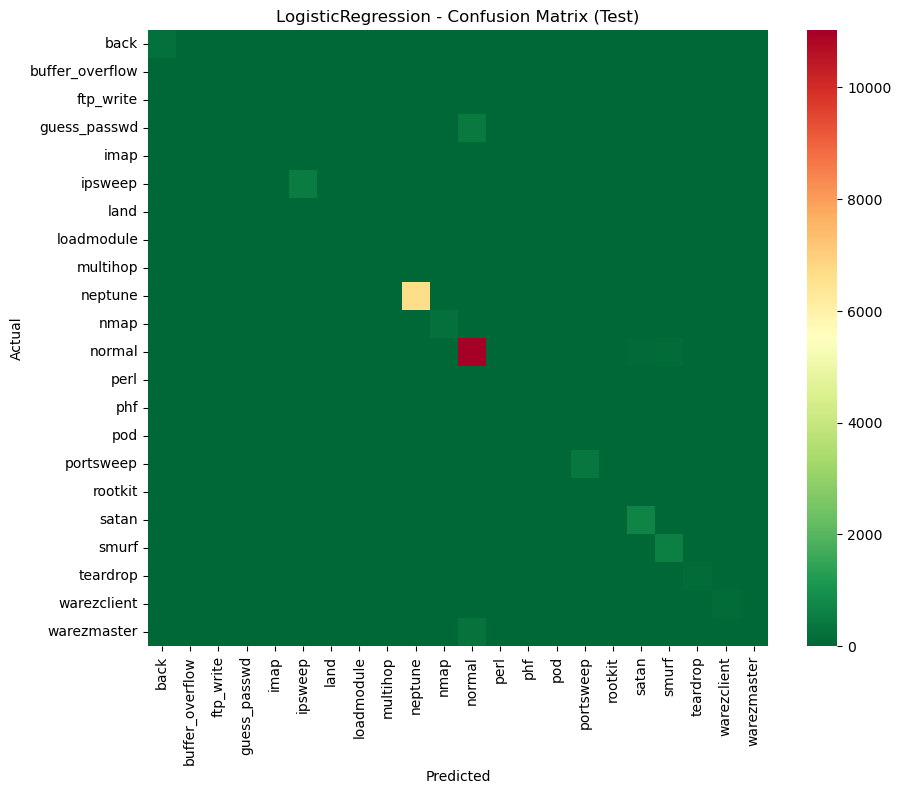

Saved TEST CM: /mnt/data/kdd_model_outputs\LogisticRegression_test_cm.png
Testing Accuracy: 0.9510

Generating multiclass ROC (One-vs-Rest)...


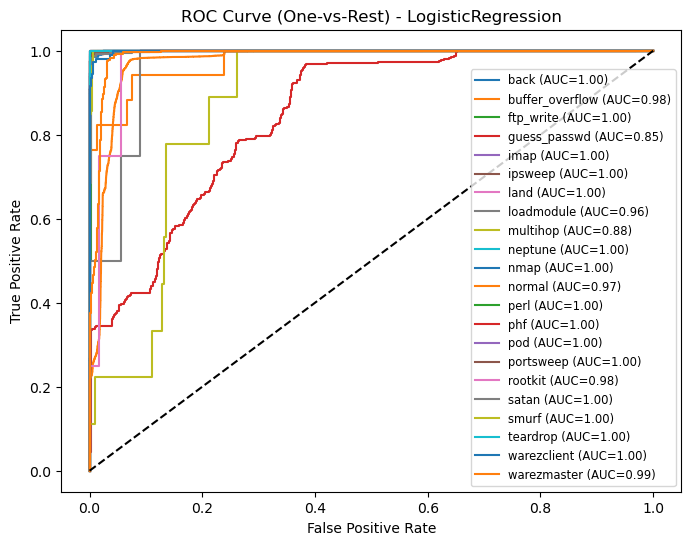

Saved ROC: /mnt/data/kdd_model_outputs\roc_LogisticRegression.png

=== Model: DecisionTree ===

Classification report (TRAIN):
                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       956
buffer_overflow       1.00      1.00      1.00        30
      ftp_write       1.00      1.00      1.00         8
   guess_passwd       1.00      1.00      1.00        53
           imap       1.00      1.00      1.00        11
        ipsweep       1.00      1.00      1.00      3599
           land       0.82      1.00      0.90        18
     loadmodule       1.00      1.00      1.00         9
       multihop       1.00      1.00      1.00         7
        neptune       1.00      1.00      1.00     41214
           nmap       1.00      0.99      1.00      1493
         normal       1.00      1.00      1.00     67343
           perl       1.00      1.00      1.00         3
            phf       1.00      1.00      1.00         4
            pod  

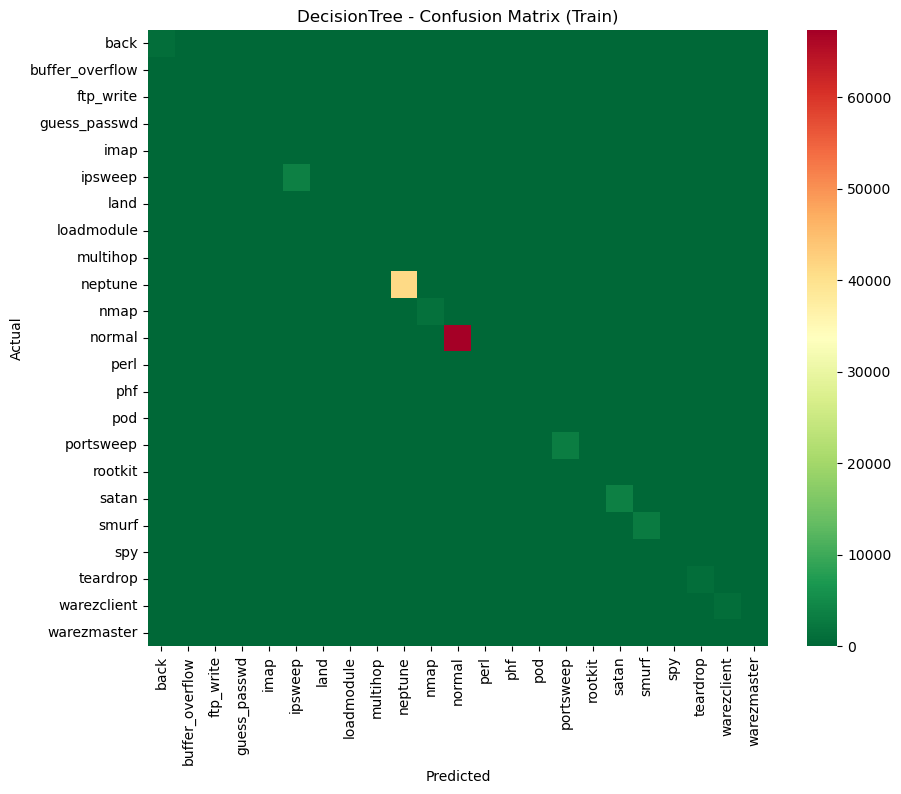

Saved TRAIN CM: /mnt/data/kdd_model_outputs\DecisionTree_train_cm.png
Training Accuracy: 0.9999

Classification report (TEST - valid labels only):
                 precision    recall  f1-score   support

           back       1.00      0.89      0.94       227
buffer_overflow       1.00      0.47      0.64        17
      ftp_write       1.00      0.50      0.67         2
   guess_passwd       0.59      0.05      0.10       411
           imap       1.00      1.00      1.00         2
        ipsweep       0.97      1.00      0.99       479
           land       1.00      1.00      1.00         2
     loadmodule       1.00      0.75      0.86         4
       multihop       0.50      0.11      0.18         9
        neptune       1.00      1.00      1.00      6654
           nmap       0.56      0.98      0.72       206
         normal       0.94      0.98      0.96     11245
           perl       1.00      1.00      1.00         1
            phf       1.00      1.00      1.00        

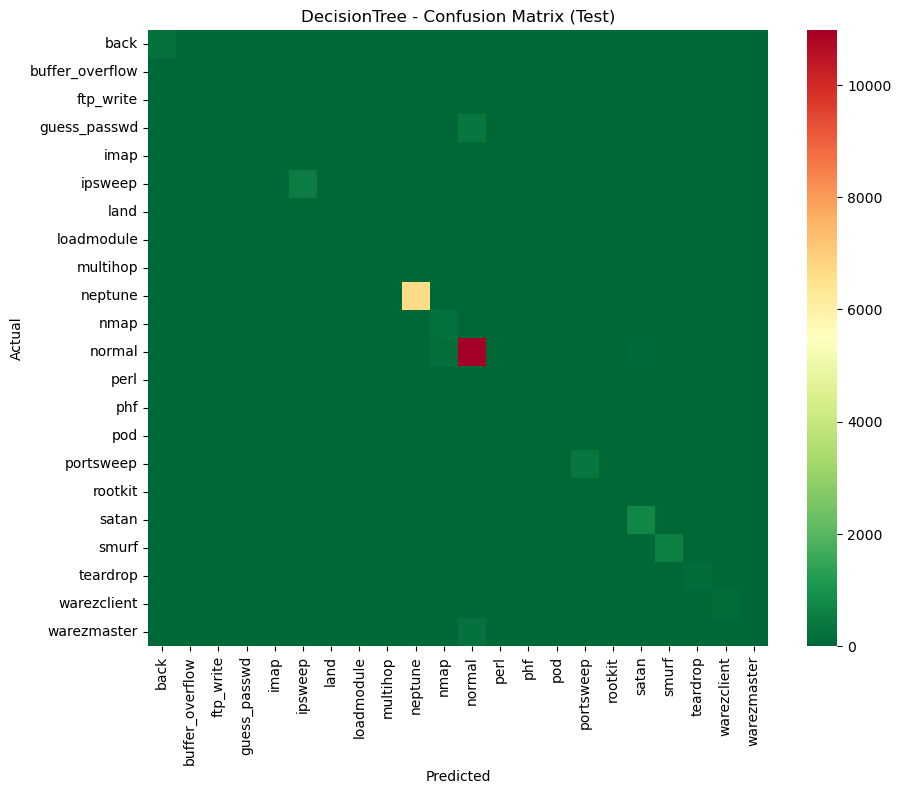

Saved TEST CM: /mnt/data/kdd_model_outputs\DecisionTree_test_cm.png
Testing Accuracy: 0.9537

Generating multiclass ROC (One-vs-Rest)...


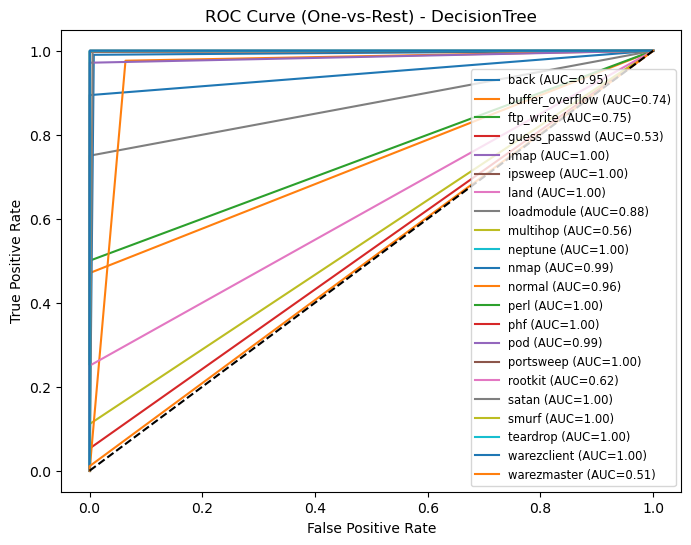

Saved ROC: /mnt/data/kdd_model_outputs\roc_DecisionTree.png

=== Model: RandomForest ===

Classification report (TRAIN):
                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       956
buffer_overflow       1.00      1.00      1.00        30
      ftp_write       1.00      1.00      1.00         8
   guess_passwd       1.00      1.00      1.00        53
           imap       1.00      1.00      1.00        11
        ipsweep       1.00      1.00      1.00      3599
           land       0.94      0.83      0.88        18
     loadmodule       1.00      1.00      1.00         9
       multihop       1.00      1.00      1.00         7
        neptune       1.00      1.00      1.00     41214
           nmap       1.00      1.00      1.00      1493
         normal       1.00      1.00      1.00     67343
           perl       1.00      1.00      1.00         3
            phf       1.00      1.00      1.00         4
            pod       1

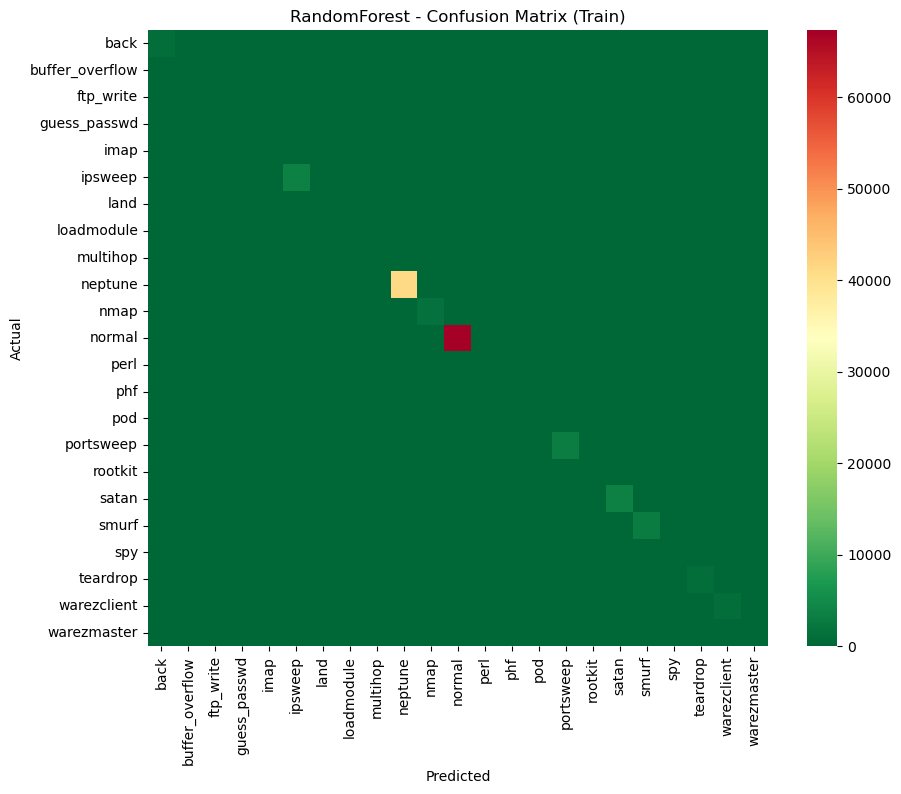

Saved TRAIN CM: /mnt/data/kdd_model_outputs\RandomForest_train_cm.png
Training Accuracy: 0.9999

Classification report (TEST - valid labels only):
                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       227
buffer_overflow       1.00      0.41      0.58        17
      ftp_write       1.00      0.50      0.67         2
   guess_passwd       1.00      0.02      0.04       411
           imap       1.00      1.00      1.00         2
        ipsweep       1.00      1.00      1.00       479
           land       1.00      0.50      0.67         2
     loadmodule       1.00      0.75      0.86         4
       multihop       1.00      0.11      0.20         9
        neptune       1.00      1.00      1.00      6654
           nmap       1.00      0.99      1.00       206
         normal       0.94      0.99      0.97     11245
           perl       0.00      0.00      0.00         1
            phf       1.00      1.00      1.00        

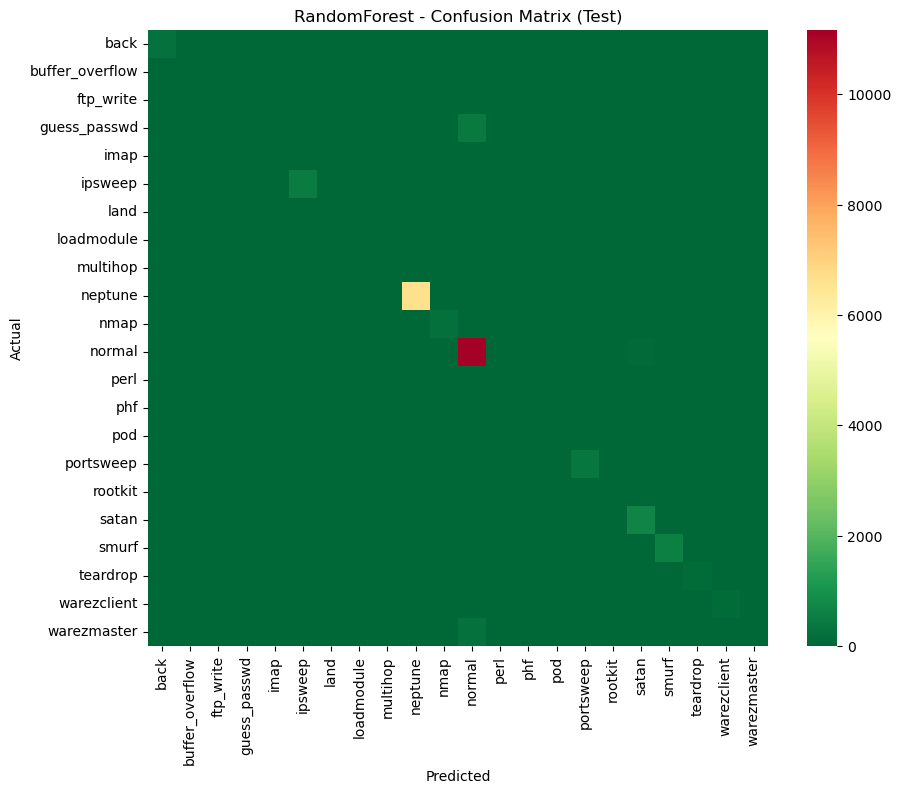

Saved TEST CM: /mnt/data/kdd_model_outputs\RandomForest_test_cm.png
Testing Accuracy: 0.9629

Generating multiclass ROC (One-vs-Rest)...


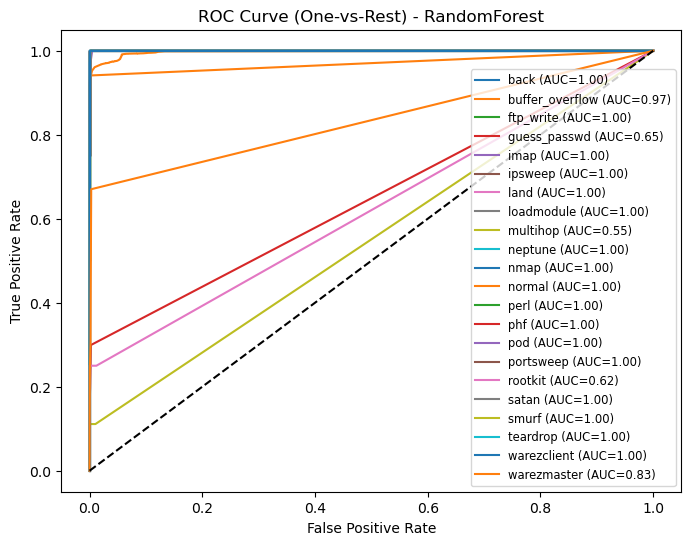

Saved ROC: /mnt/data/kdd_model_outputs\roc_RandomForest.png

=== Model: HistGradientBoosting ===

Classification report (TRAIN):
                 precision    recall  f1-score   support

           back       0.98      1.00      0.99       956
buffer_overflow       0.02      0.23      0.04        30
      ftp_write       0.00      0.00      0.00         8
   guess_passwd       0.98      0.94      0.96        53
           imap       0.01      0.55      0.03        11
        ipsweep       0.99      0.94      0.97      3599
           land       0.01      0.17      0.02        18
     loadmodule       0.00      0.00      0.00         9
       multihop       0.00      0.00      0.00         7
        neptune       1.00      0.99      1.00     41214
           nmap       0.92      0.99      0.95      1493
         normal       1.00      0.97      0.98     67343
           perl       0.00      0.00      0.00         3
            phf       0.00      0.00      0.00         4
            pod

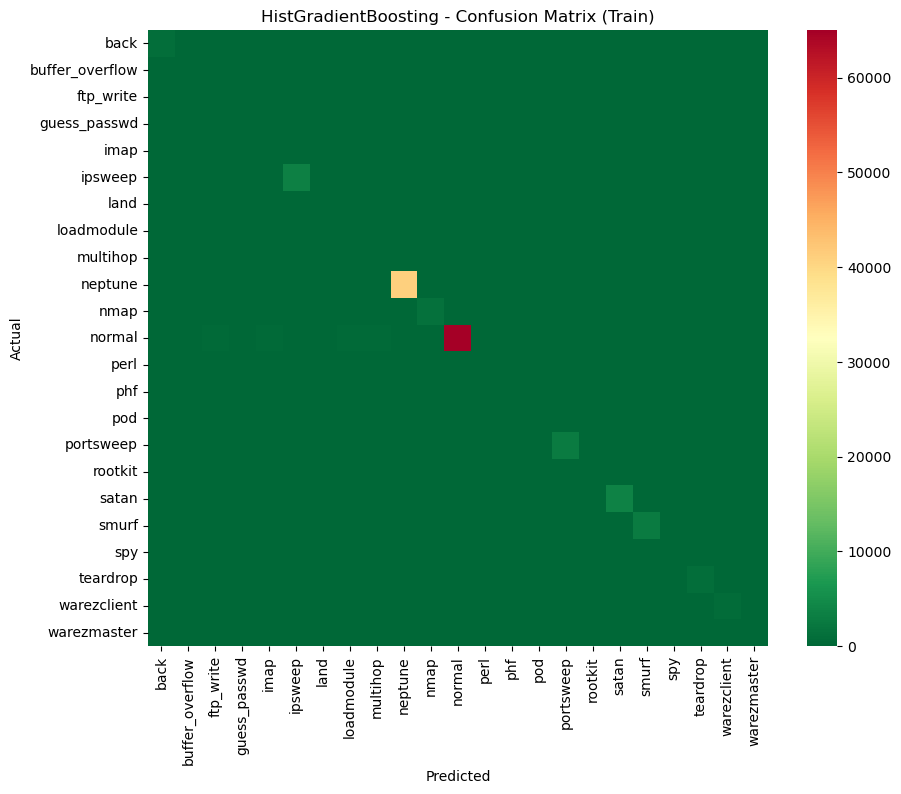

Saved TRAIN CM: /mnt/data/kdd_model_outputs\HistGradientBoosting_train_cm.png
Training Accuracy: 0.9729

Classification report (TEST - valid labels only):
                 precision    recall  f1-score   support

           back       0.99      1.00      1.00       227
buffer_overflow       0.03      0.06      0.04        17
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       1.00      0.02      0.04       411
           imap       0.01      0.50      0.02         2
        ipsweep       0.99      0.93      0.96       479
           land       0.00      0.00      0.00         2
     loadmodule       0.00      0.00      0.00         4
       multihop       0.00      0.00      0.00         9
        neptune       1.00      0.99      1.00      6654
           nmap       0.93      0.97      0.95       206
         normal       0.95      0.96      0.96     11245
           perl       0.00      0.00      0.00         1
            phf       0.00      0.00      0.00

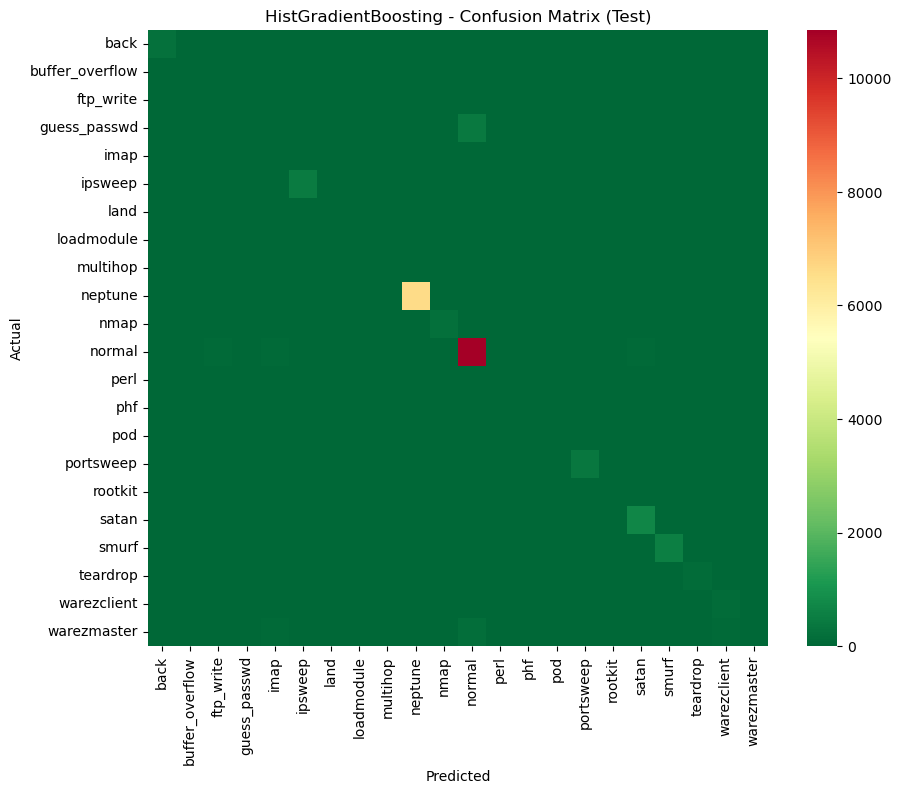

Saved TEST CM: /mnt/data/kdd_model_outputs\HistGradientBoosting_test_cm.png
Testing Accuracy: 0.9414

Generating multiclass ROC (One-vs-Rest)...


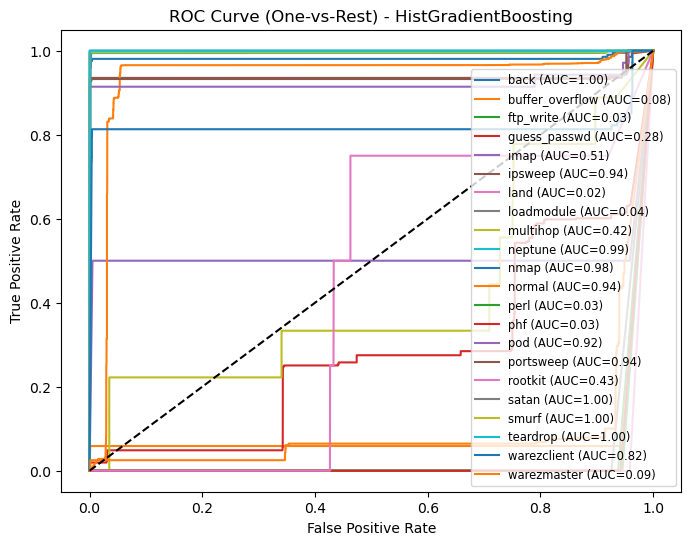

Saved ROC: /mnt/data/kdd_model_outputs\roc_HistGradientBoosting.png


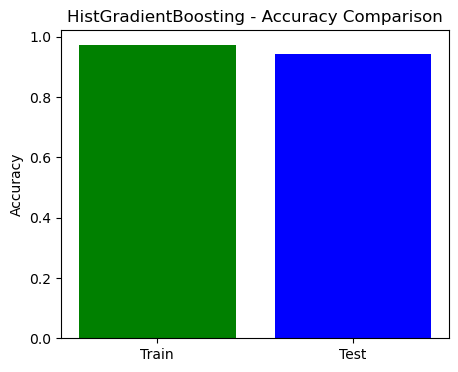

Saved Accuracy Chart: /mnt/data/kdd_model_outputs\HistGradientBoosting_accuracy.png


In [123]:
# ---------- Training & evaluation loop WITH CM + ROC ----------
import seaborn as sns
import matplotlib.pyplot as plt

results = []

for name, model in models.items():

    print(f"\n=== Model: {name} ===")
    model.fit(X_train_scaled, y_train)

    # predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test  = model.predict(X_test_scaled)

    # valid test mask
    valid_mask = (y_test_mapped != -1)
    valid_count = int(valid_mask.sum())

    # TRAIN metrics
    acc_tr  = accuracy_score(y_train, y_pred_train)
    prec_tr = precision_score(y_train, y_pred_train, average='weighted', zero_division=0)
    rec_tr  = recall_score(y_train, y_pred_train, average='weighted', zero_division=0)
    f1_tr   = f1_score(y_train, y_pred_train, average='weighted', zero_division=0)

    # TEST metrics
    if valid_count > 0:
        acc_te  = accuracy_score(y_test_mapped[valid_mask], y_pred_test[valid_mask])
        prec_te = precision_score(y_test_mapped[valid_mask], y_pred_test[valid_mask],
                                  average='weighted', zero_division=0)
        rec_te  = recall_score(y_test_mapped[valid_mask], y_pred_test[valid_mask],
                               average='weighted', zero_division=0)
        f1_te   = f1_score(y_test_mapped[valid_mask], y_pred_test[valid_mask],
                           average='weighted', zero_division=0)
    else:
        acc_te = prec_te = rec_te = f1_te = np.nan

    # append results
    results.append({
        "model": name,
        "train_rows": X_train_scaled.shape[0],
        "test_rows_total": X_test_scaled.shape[0],
        "test_rows_valid": valid_count,
        "accuracy_train": acc_tr,
        "precision_train": prec_tr,
        "recall_train": rec_tr,
        "f1_train": f1_tr,
        "accuracy_test": acc_te,
        "precision_test": prec_te,
        "recall_test": rec_te,
        "f1_test": f1_te
    })

    # ---------------- TRAIN REPORT ----------------
    print("\nClassification report (TRAIN):")
    print(classification_report(
        y_train, y_pred_train,
        zero_division=0,
        target_names=list(le.classes_)
    ))

    # ---------------- TRAIN CONFUSION MATRIX ----------------
    cm_train = confusion_matrix(y_train, y_pred_train, labels=range(len(le.classes_)))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_train, cmap='RdYlGn_r',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} - Confusion Matrix (Train)")
    train_cm_path = os.path.join(out_dir, f"{name}_train_cm.png")
    plt.savefig(train_cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved TRAIN CM:", train_cm_path)
    print(f"Training Accuracy: {acc_tr:.4f}")

    

    # ---------------- TEST REPORT ----------------
    if valid_count > 0:
        valid_labels = sorted(np.unique(y_test_mapped[valid_mask]))

        print("\nClassification report (TEST - valid labels only):")
        print(classification_report(
            y_test_mapped[valid_mask],
            y_pred_test[valid_mask],
            labels=valid_labels,
            target_names=[le.classes_[i] for i in valid_labels],
            zero_division=0
        ))

        # ---------------- TEST CONFUSION MATRIX ----------------
        cm_test = confusion_matrix(
            y_test_mapped[valid_mask],
            y_pred_test[valid_mask],
            labels=valid_labels
        )
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm_test, cmap='RdYlGn_r',
                    xticklabels=[le.classes_[i] for i in valid_labels],
                    yticklabels=[le.classes_[i] for i in valid_labels])
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"{name} - Confusion Matrix (Test)")
        test_cm_path = os.path.join(out_dir, f"{name}_test_cm.png")
        plt.savefig(test_cm_path, dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved TEST CM:", test_cm_path)
        print(f"Testing Accuracy: {acc_te:.4f}")


    else:
        print("No valid test rows to evaluate.")

    # ---------------- ROC CURVE (One-vs-Rest) ----------------
    if hasattr(model, "predict_proba") and valid_count > 0:
        print("\nGenerating multiclass ROC (One-vs-Rest)...")

        classes_range = range(len(le.classes_))

        # binarize the test labels
        y_test_bin = label_binarize(y_test_mapped[valid_mask], classes=classes_range)

        # probabilities for each class
        y_score = model.predict_proba(X_test_scaled[valid_mask])

        plt.figure(figsize=(8, 6))
        for cls_index in valid_labels:
            try:
                fpr, tpr, _ = roc_curve(
                    y_test_bin[:, cls_index],
                    y_score[:, cls_index]
                )
                roc_auc = auc(fpr, tpr)

                plt.plot(fpr, tpr,
                         label=f"{le.classes_[cls_index]} (AUC={roc_auc:.2f})")

            except Exception as e:
                print(f"Skipped ROC for class {cls_index}: {e}")

        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve (One-vs-Rest) - {name}")
        plt.legend(loc="lower right", fontsize='small')

        roc_path = os.path.join(out_dir, f"roc_{name}.png")
        plt.savefig(roc_path, dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved ROC:", roc_path)

    else:
        print("Skipping ROC (no predict_proba or no valid labels).")

# ---------------- ACCURACY PLOT ----------------
plt.figure(figsize=(5,4))
plt.bar(["Train", "Test"], [acc_tr, acc_te], color=["green", "blue"])
plt.ylabel("Accuracy")
plt.title(f"{name} - Accuracy Comparison")
acc_path = os.path.join(out_dir, f"{name}_accuracy.png")
plt.savefig(acc_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved Accuracy Chart:", acc_path)



In [111]:
# --------- After loop: results summary and comparison plots ----------
results_df = pd.DataFrame(results)
summary_csv = os.path.join(out_dir, "model_metrics_summary.csv")
results_df.to_csv(summary_csv, index=False)
print("\nSaved metrics summary to:", summary_csv)
safe_display_df(results_df, "Model metrics (train vs test)")


Saved metrics summary to: /mnt/data/kdd_model_outputs\model_metrics_summary.csv


,model,train_rows,test_rows_total,test_rows_valid,accuracy_train,precision_train,recall_train,f1_train,accuracy_test,precision_test,recall_test,f1_test
0,LogisticRegression,125973,22544,21398,0.993173,0.993132,0.993173,0.993092,0.950977,0.953638,0.950977,0.936001
1,DecisionTree,125973,22544,21398,0.999873,0.999879,0.999873,0.999874,0.953687,0.951443,0.953687,0.940842
2,RandomForest,125973,22544,21398,0.999873,0.999872,0.999873,0.999872,0.962940,0.964938,0.962940,0.947818
3,HistGradientBoosting,125973,22544,21398,0.972923,0.993921,0.972923,0.983118,0.941396,0.952980,0.941396,0.937006


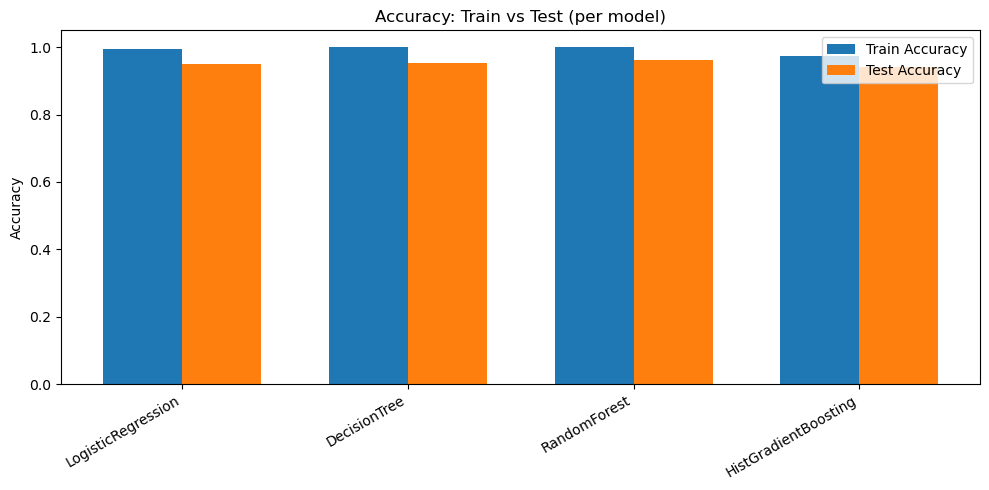

Saved: /mnt/data/kdd_model_outputs\accuracy_train_vs_test.png


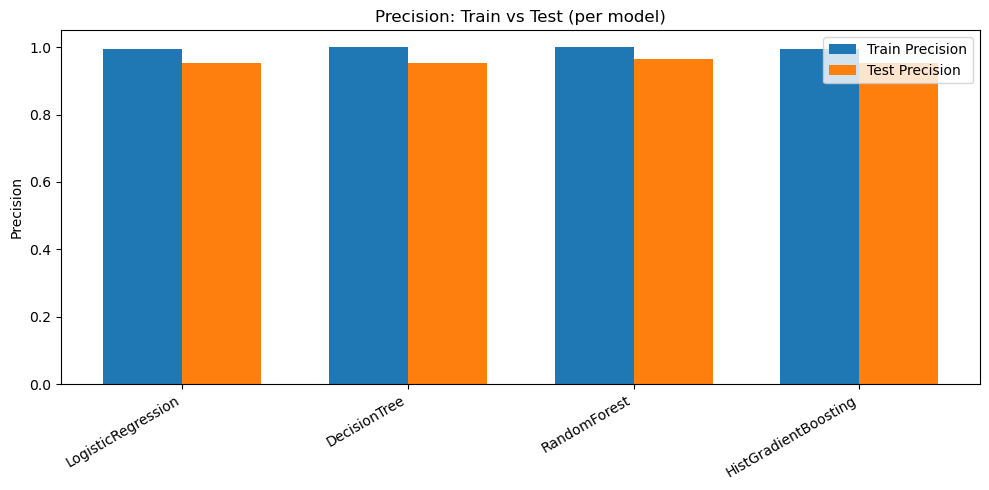

Saved: /mnt/data/kdd_model_outputs\precision_train_vs_test.png


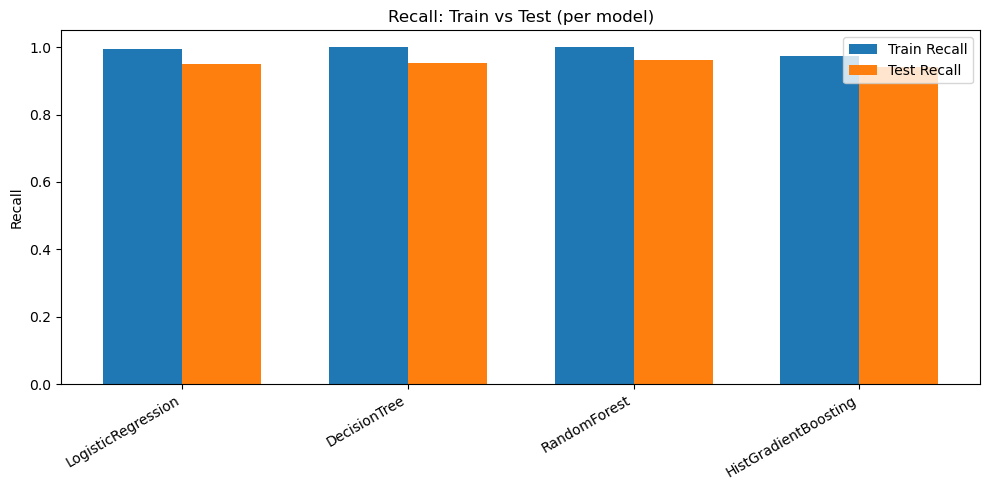

Saved: /mnt/data/kdd_model_outputs\recall_train_vs_test.png


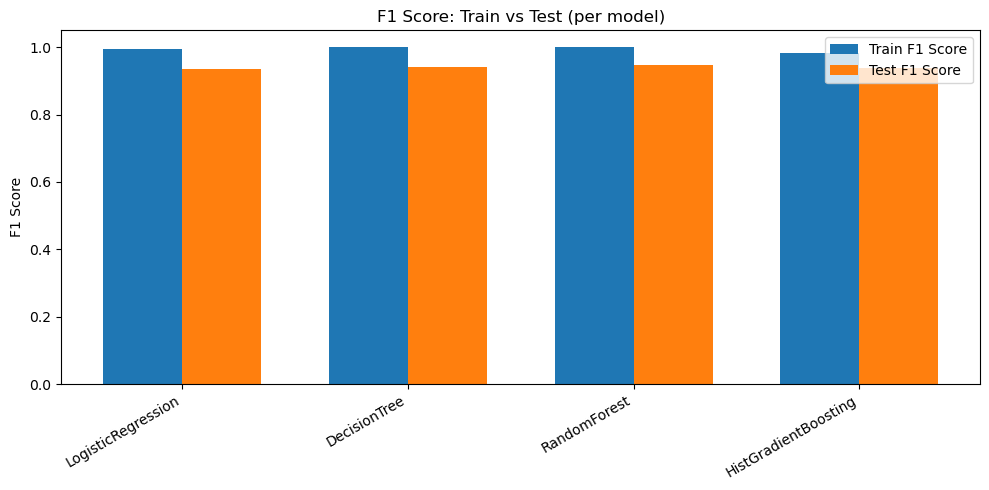

Saved: /mnt/data/kdd_model_outputs\f1_score_train_vs_test.png

All outputs saved to: /mnt/data/kdd_model_outputs


In [125]:
# Comparison bar plots: train vs test for Accuracy/Precision/Recall/F1
metrics_pairs = [
    ("accuracy_train", "accuracy_test", "Accuracy"),
    ("precision_train", "precision_test", "Precision"),
    ("recall_train", "recall_test", "Recall"),
    ("f1_train", "f1_test", "F1 Score")
]

for train_col, test_col, metric_name in metrics_pairs:
    plt.figure(figsize=(10,5))
    x = np.arange(len(results_df))
    width = 0.35
    plt.bar(x - width/2, results_df[train_col], width=width, label=f"Train {metric_name}")
    plt.bar(x + width/2, results_df[test_col], width=width, label=f"Test {metric_name}")
    plt.xticks(x, results_df["model"], rotation=30, ha='right')
    plt.ylabel(metric_name)
    plt.title(f"{metric_name}: Train vs Test (per model)")
    plt.legend()
    plt.tight_layout()
    plot_path = os.path.join(out_dir, f"{metric_name.replace(' ', '_').lower()}_train_vs_test.png")
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print("Saved:", plot_path)

print("\nAll outputs saved to:", out_dir)